In [ ]:
!pip uninstall scikit-learn -y
!pip install --upgrade pip
!pip install scikit-learn

In [ ]:
!pip uninstall imbalanced-learn -y
!pip install imbalanced-learn

### BERT

Epoch 1, Loss: 2.79
Validation Loss: 2.22
Validation loss improved. Saving model...
Epoch 2, Loss: 1.86
Validation Loss: 1.63
Validation loss improved. Saving model...
Epoch 3, Loss: 1.27
Validation Loss: 1.41
Validation loss improved. Saving model...
Epoch 4, Loss: 0.88
Validation Loss: 1.34
Validation loss improved. Saving model...
Epoch 5, Loss: 0.60
Validation Loss: 1.38
Validation loss did not improve for 1 epoch(s).
Epoch 6, Loss: 0.44
Validation Loss: 1.47
Validation loss did not improve for 2 epoch(s).
Early stopping triggered.
Early stopping triggered.
Training complete


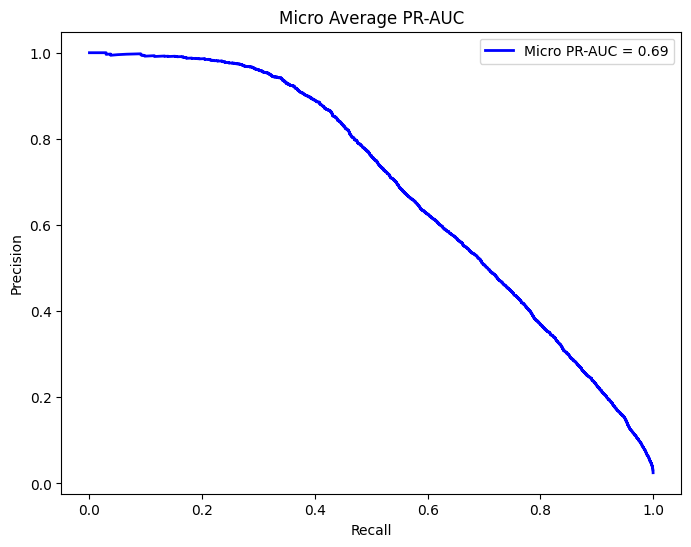

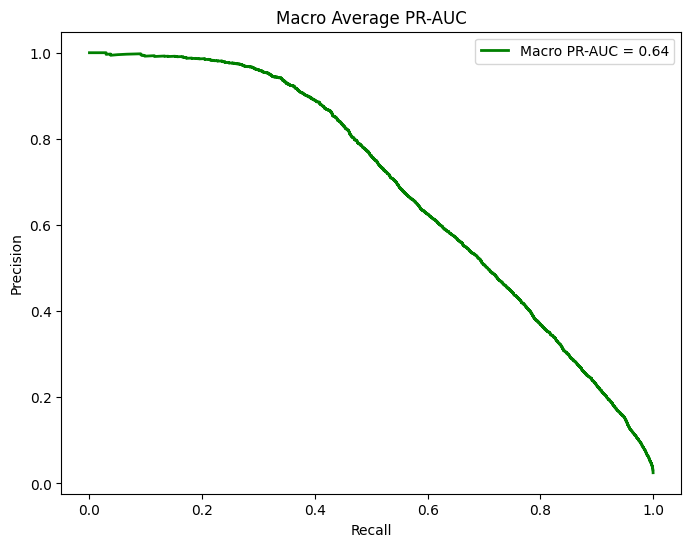

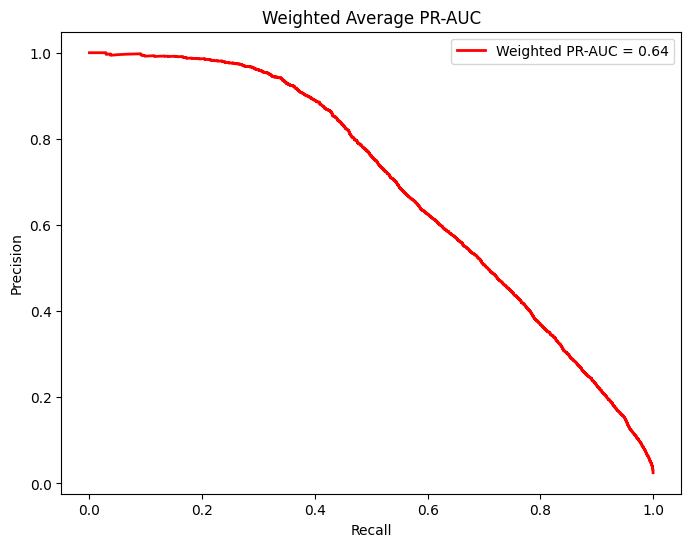


PR-AUC Scores:
- Micro:    0.6864
- Macro:    0.6380
- Weighted: 0.6392


In [3]:
import pandas as pd
import re
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve, average_precision_score
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Load BERT model and tokenizer for classification
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=40)

# Enable gradient checkpointing to reduce memory usage
model.gradient_checkpointing_enable()

# Function to preprocess text
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'\([^)]*\)', '', text)
    text = re.sub('"', '', text)
    text = re.sub(r"'s\b", "", text)
    text = re.sub("[^a-zA-Z]", " ", text)
    return text.strip()

# Load data
data = pd.read_csv('/kaggle/input/medicaltranscriptions/mtsamples.csv')
data.drop('Unnamed: 0', axis=1, inplace=True)

# Clean transcription
data['cleaned_transcription'] = data['transcription'].apply(preprocess_text)

# Tokenize and encode the texts
def encode_texts(texts):
    inputs = tokenizer(texts.tolist(), return_tensors='pt', padding=True, truncation=True, max_length=64)
    return inputs['input_ids'], inputs['attention_mask']

# Create embeddings for transcripts
input_ids, attention_masks = encode_texts(data.cleaned_transcription)

# Label encode our categorical target variable
le = LabelEncoder()
Y = le.fit_transform(data.medical_specialty.values)

# Applying SMOTE to balance classes
sm = SMOTE()
X_res, Y_res = sm.fit_resample(input_ids.numpy(), Y)

# Splitting data into train:test
X_train, X_val, Y_train, Y_val = train_test_split(X_res, Y_res, test_size=0.2, random_state=42)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.long)  # Use long for indices
Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.long)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Training function with Early Stopping
def train_model_with_early_stopping(model, train_dataloader, val_dataloader, num_epochs=10, patience=2):
    optimizer = AdamW(model.parameters(), lr=5e-5)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    best_val_loss = float('inf')  # Start with a very high value
    epochs_without_improvement = 0  # Counter for early stopping
    early_stop = False  # Flag to check if early stopping is triggered

    for epoch in range(num_epochs):
        if early_stop:
            print("Early stopping triggered.")
            break

        model.train()
        total_loss = 0

        # Training loop
        for batch in train_dataloader:
            optimizer.zero_grad()
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(input_ids=inputs, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

        avg_loss = total_loss / len(train_dataloader)
        print(f"Epoch {epoch + 1}, Loss: {avg_loss:.2f}")

        # Validation
        model.eval()
        val_loss = 0.0
        val_preds, val_labels = [], []
        with torch.no_grad():
            for batch in val_dataloader:
                inputs, labels = batch
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(input_ids=inputs, labels=labels)
                val_loss += outputs.loss.item()
                val_preds.append(torch.softmax(outputs.logits, dim=1).cpu().numpy())  # Use softmax for probabilities
                val_labels.append(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_dataloader)
        print(f"Validation Loss: {avg_val_loss:.2f}")

        # Check for improvement in validation loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0  # Reset counter
            print("Validation loss improved. Saving model...")
            torch.save(model.state_dict(), 'best_model.pth')  # Save the best model
        else:
            epochs_without_improvement += 1
            print(f"Validation loss did not improve for {epochs_without_improvement} epoch(s).")

        # Early stopping condition
        if epochs_without_improvement >= patience:
            early_stop = True
            print("Early stopping triggered.")

    print("Training complete")

    # After training, evaluate on the validation set
    model.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for batch in val_dataloader:
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(input_ids=inputs, labels=labels)
            val_preds.append(torch.softmax(outputs.logits, dim=1).cpu().numpy())  # Use softmax for probabilities
            val_labels.append(labels.cpu().numpy())

    val_preds = np.concatenate(val_preds)
    val_labels = np.concatenate(val_labels)

    # Compute PR-AUC for micro, macro, and weighted
    val_labels_bin = label_binarize(val_labels, classes=np.arange(len(le.classes_)))

    # PR-AUC for Micro Average
    precision_micro, recall_micro, _ = precision_recall_curve(val_labels_bin.ravel(), val_preds.ravel())
    pr_auc_micro = average_precision_score(val_labels_bin, val_preds, average='micro')

    # PR-AUC for Macro Average
    precision_macro, recall_macro, _ = precision_recall_curve(val_labels_bin.ravel(), val_preds.ravel())
    pr_auc_macro = average_precision_score(val_labels_bin, val_preds, average='macro')

    # PR-AUC for Weighted Average
    precision_weighted, recall_weighted, _ = precision_recall_curve(val_labels_bin.ravel(), val_preds.ravel())
    pr_auc_weighted = average_precision_score(val_labels_bin, val_preds, average='weighted')

    # Plot Micro Average PR-AUC
    plt.figure(figsize=(8, 6))
    plt.plot(recall_micro, precision_micro, color='blue', lw=2, label=f'Micro PR-AUC = {pr_auc_micro:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Micro Average PR-AUC')
    plt.legend()
    plt.show()

    # Plot Macro Average PR-AUC
    plt.figure(figsize=(8, 6))
    plt.plot(recall_macro, precision_macro, color='green', lw=2, label=f'Macro PR-AUC = {pr_auc_macro:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Macro Average PR-AUC')
    plt.legend()
    plt.show()

    # Plot Weighted Average PR-AUC
    plt.figure(figsize=(8, 6))
    plt.plot(recall_weighted, precision_weighted, color='red', lw=2, label=f'Weighted PR-AUC = {pr_auc_weighted:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Weighted Average PR-AUC')
    plt.legend()
    plt.show()

    # Print PR-AUC Scores
    print(f"\nPR-AUC Scores:")
    print(f"- Micro:    {pr_auc_micro:.4f}")
    print(f"- Macro:    {pr_auc_macro:.4f}")
    print(f"- Weighted: {pr_auc_weighted:.4f}")

# Train the model with early stopping and evaluate
train_model_with_early_stopping(model, train_dataloader, val_dataloader, num_epochs=10, patience=2)

Epoch 1, Loss: 3.05
Validation Loss: 2.56
Validation loss improved. Saving model...
Validation Accuracy: 30.35%
                                precision    recall  f1-score   support

          Allergy / Immunology     0.7748    0.5021    0.6094       233
                       Autopsy     0.2200    0.8527    0.3498       224
                    Bariatrics     0.3919    0.1245    0.1889       233
    Cardiovascular / Pulmonary     0.1667    0.0147    0.0270       204
                  Chiropractic     0.0000    0.0000    0.0000       212
    Consult - History and Phy.     0.2786    0.3861    0.3237       202
    Cosmetic / Plastic Surgery     0.1620    0.5450    0.2497       211
                     Dentistry     0.3017    0.3106    0.3061       235
                   Dermatology     0.0000    0.0000    0.0000       211
          Diets and Nutritions     0.6748    0.9955    0.8044       221
             Discharge Summary     0.6667    0.3881    0.4906       201
          ENT - Otolary

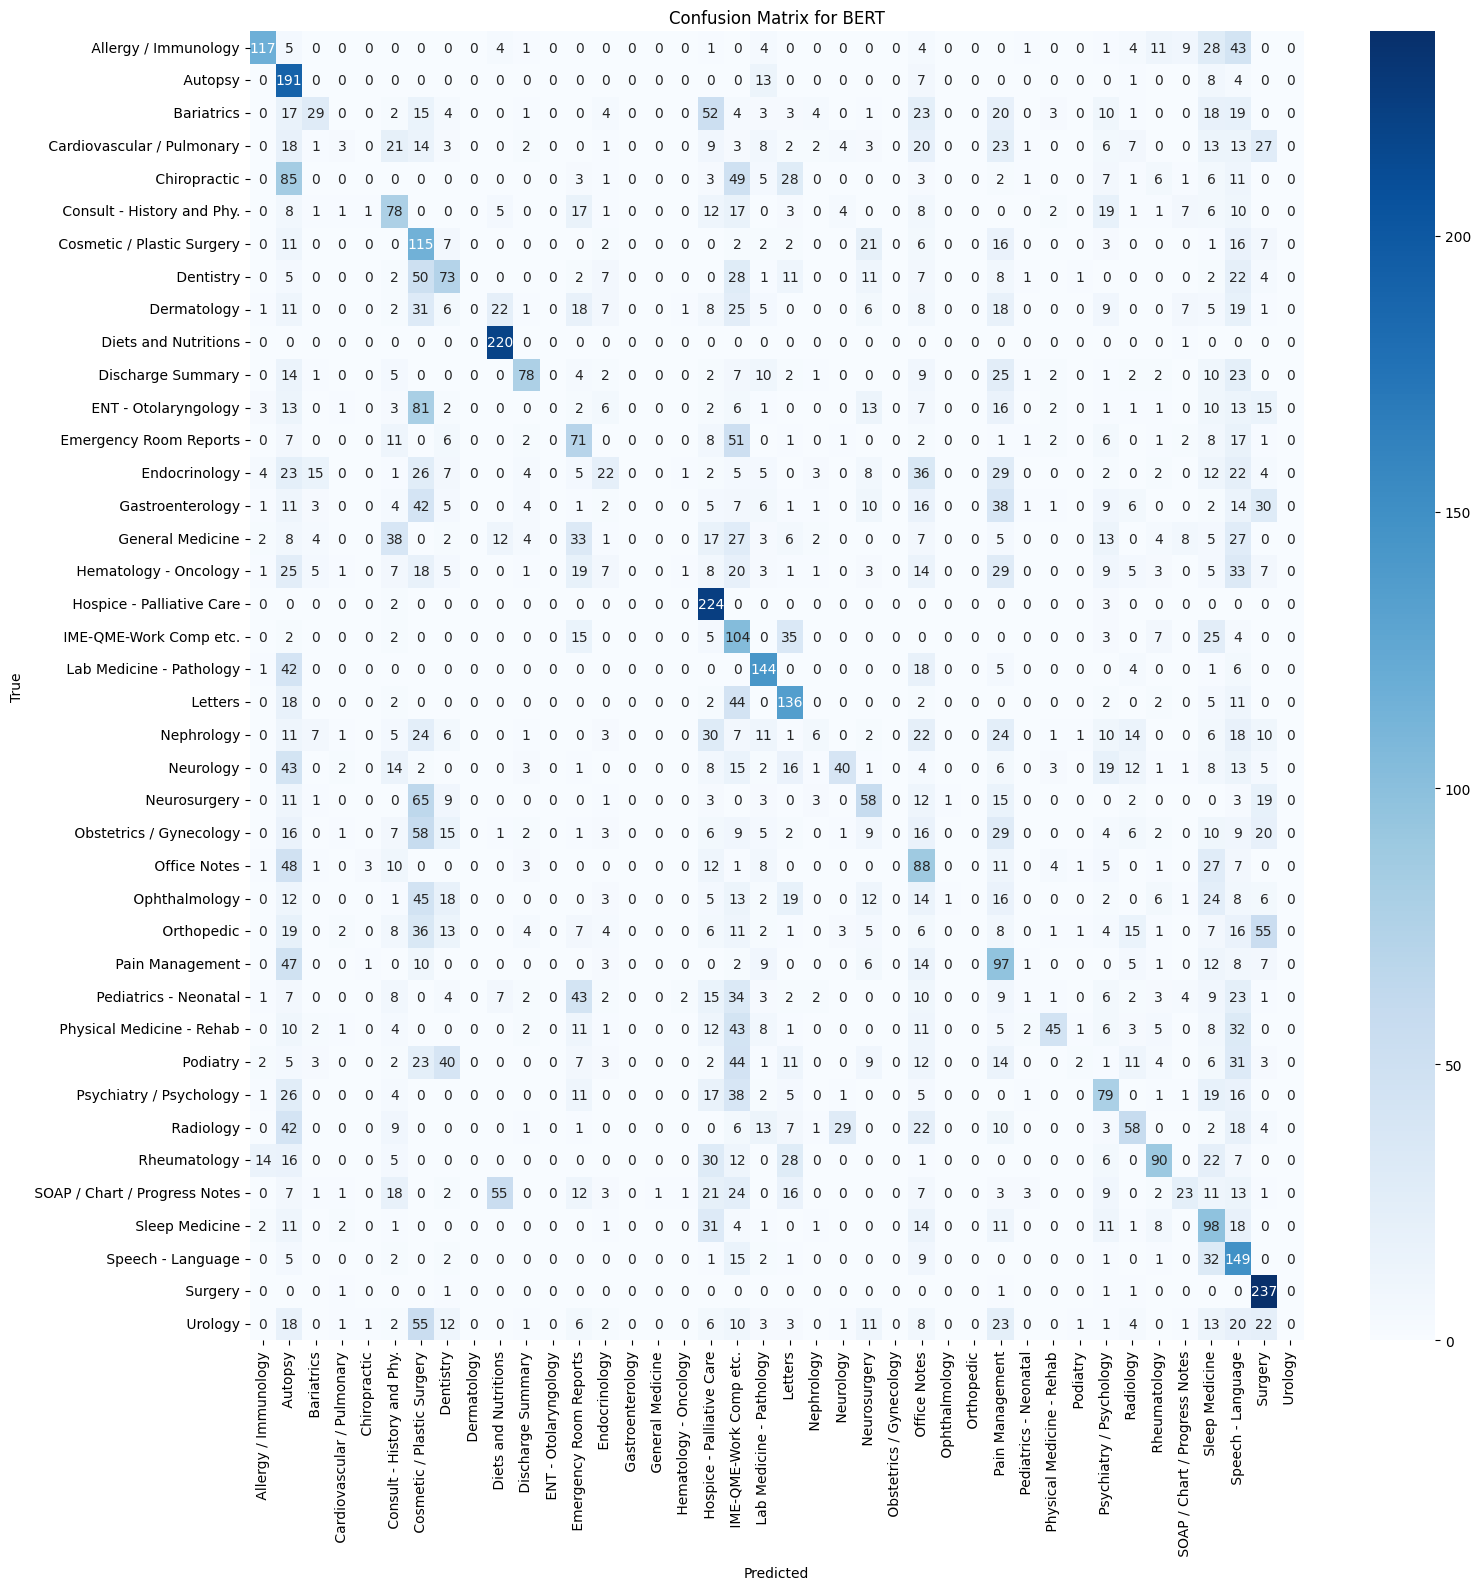

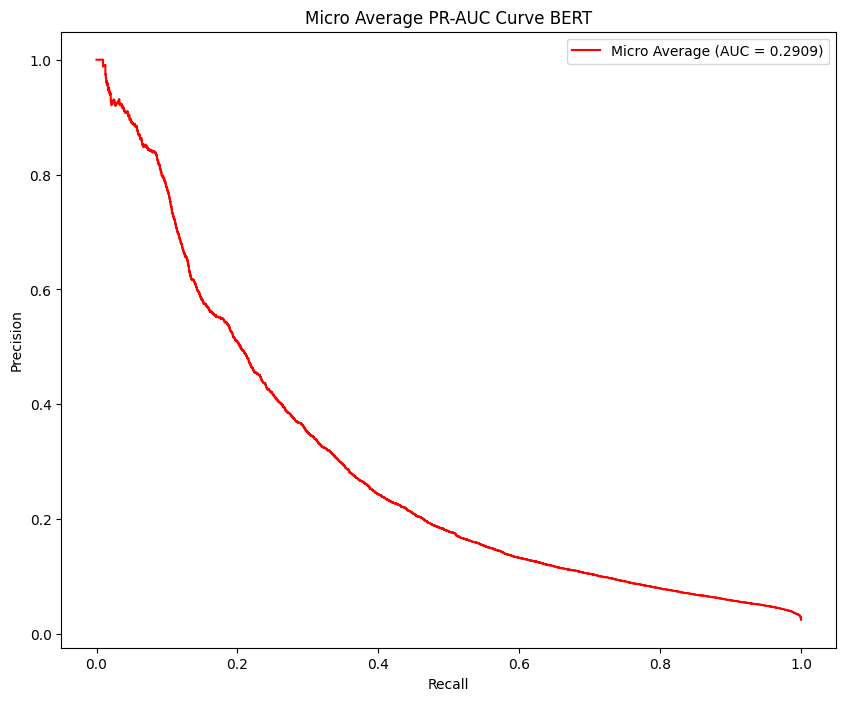

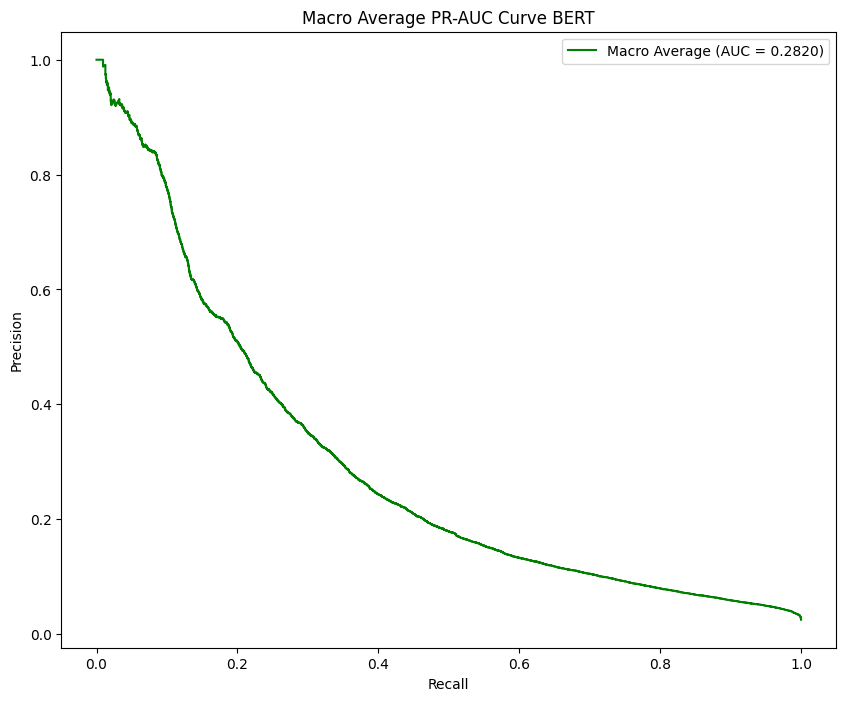

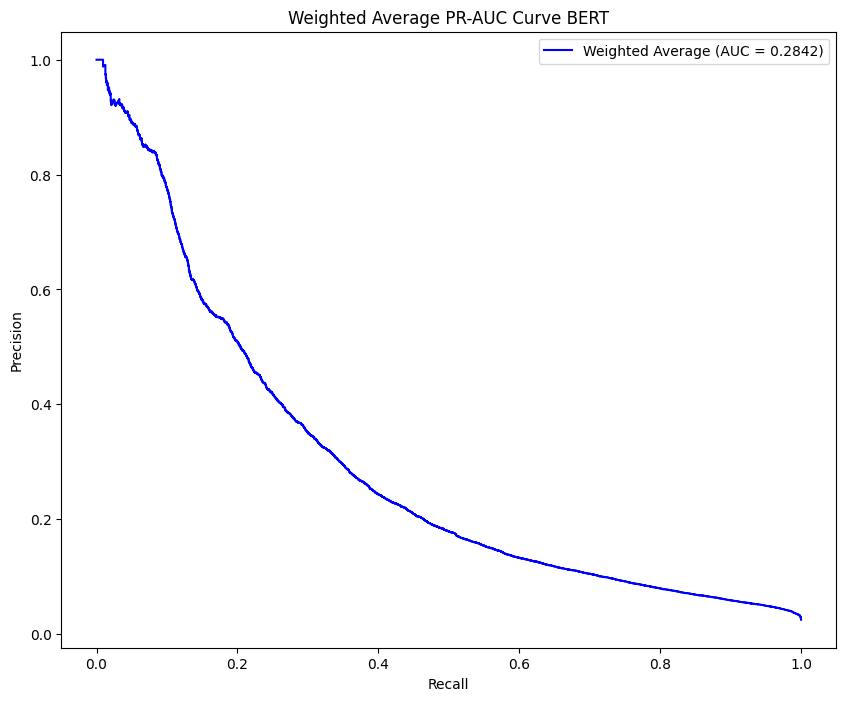

Epoch 2, Loss: 2.21
Validation Loss: 1.99
Validation loss improved. Saving model...
Validation Accuracy: 45.34%
                                precision    recall  f1-score   support

          Allergy / Immunology     0.8125    0.9485    0.8752       233
                       Autopsy     0.8646    0.8839    0.8742       224
                    Bariatrics     0.5774    0.5923    0.5847       233
    Cardiovascular / Pulmonary     0.1765    0.0735    0.1038       204
                  Chiropractic     0.6011    0.5330    0.5650       212
    Consult - History and Phy.     0.2615    0.3663    0.3052       202
    Cosmetic / Plastic Surgery     0.2290    0.5166    0.3173       211
                     Dentistry     0.2089    0.7957    0.3310       235
                   Dermatology     0.1837    0.2133    0.1974       211
          Diets and Nutritions     0.8669    0.9729    0.9168       221
             Discharge Summary     0.5580    0.5025    0.5288       201
          ENT - Otolary

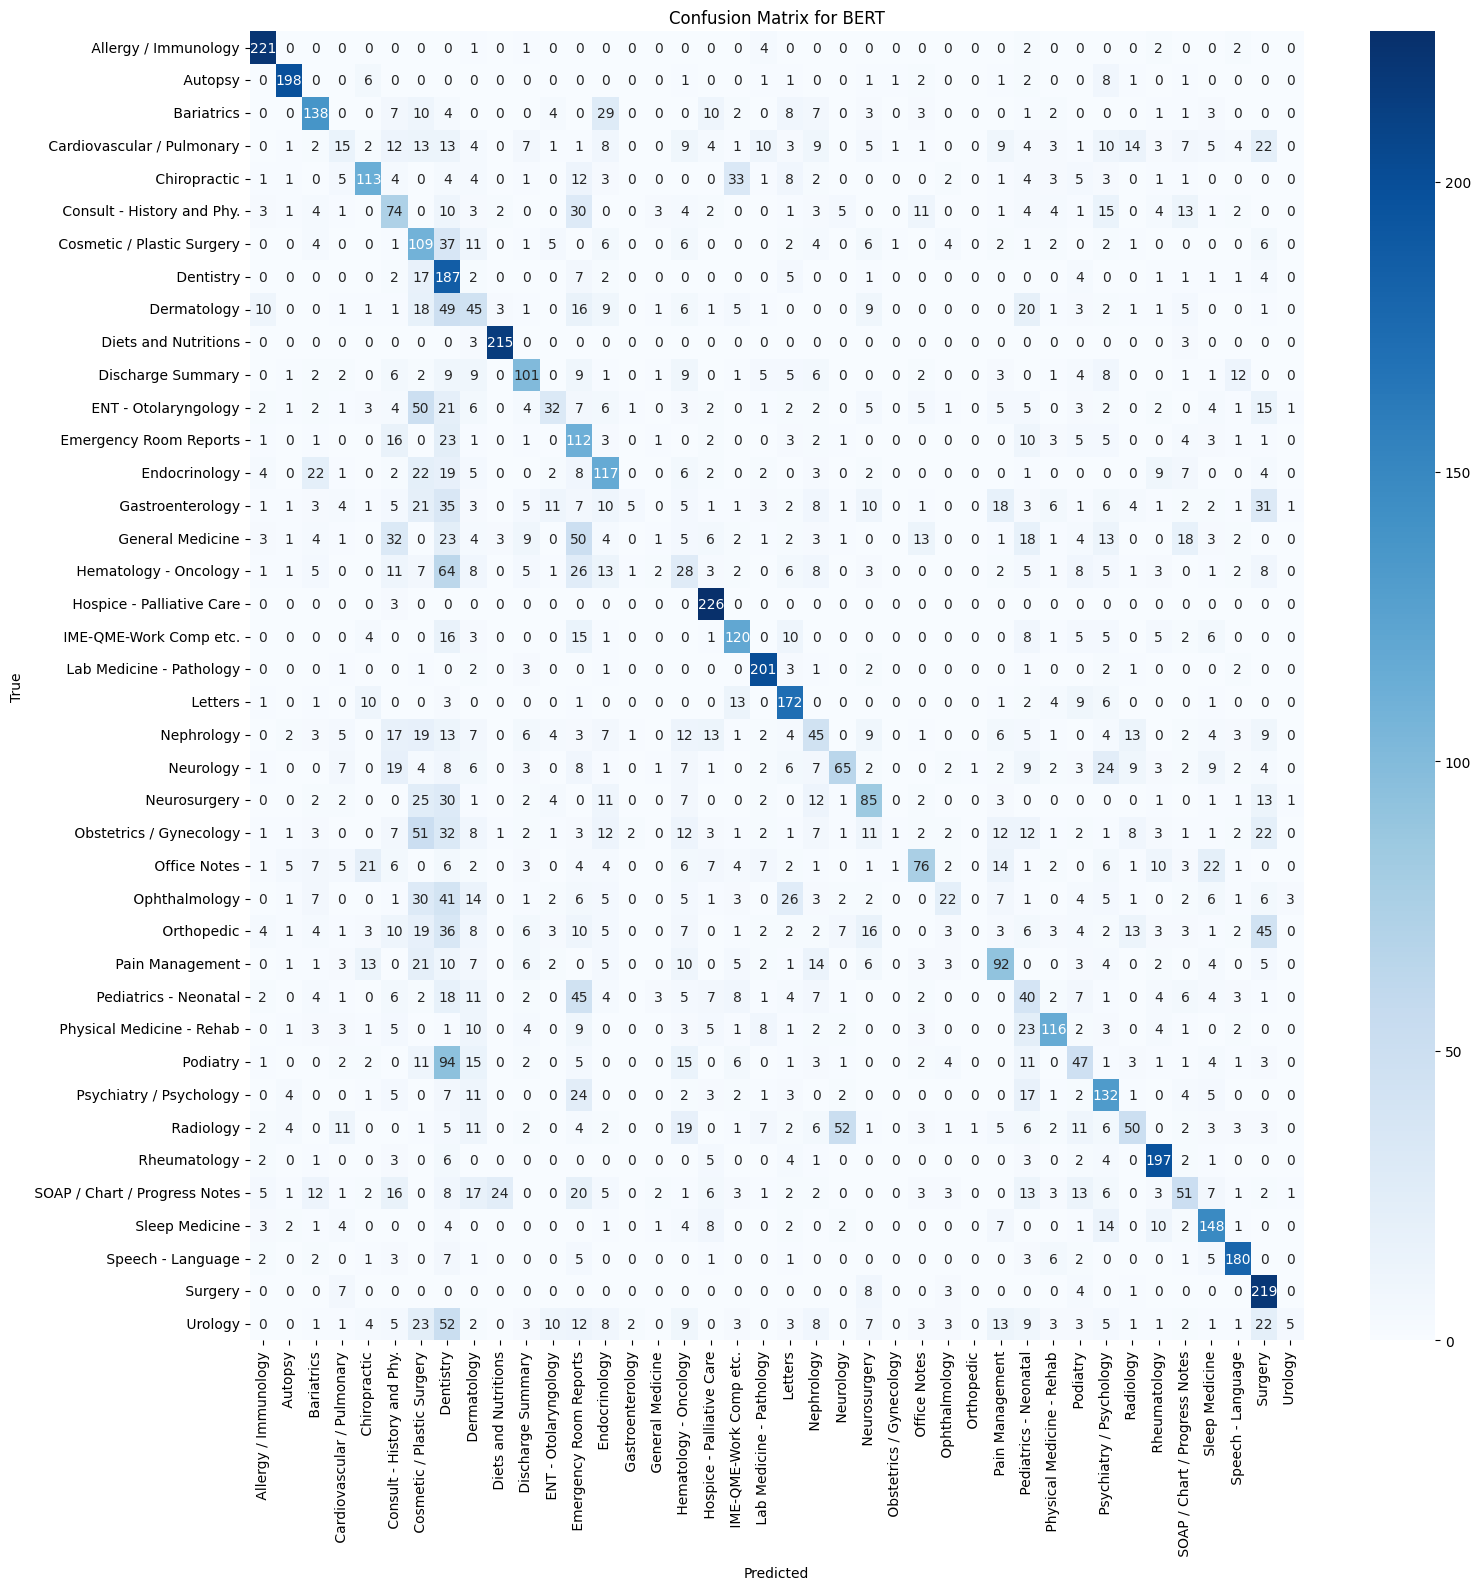

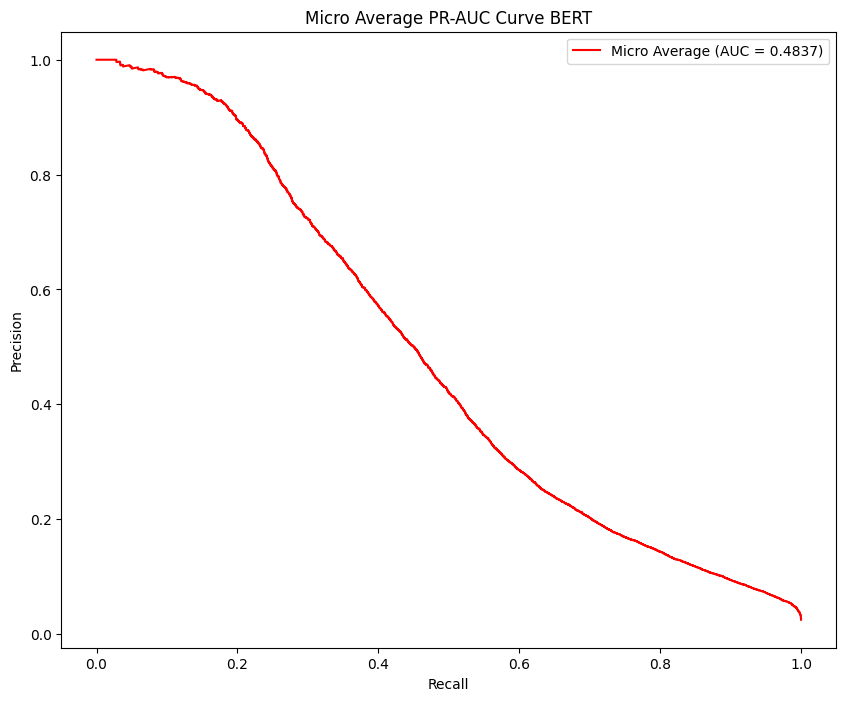

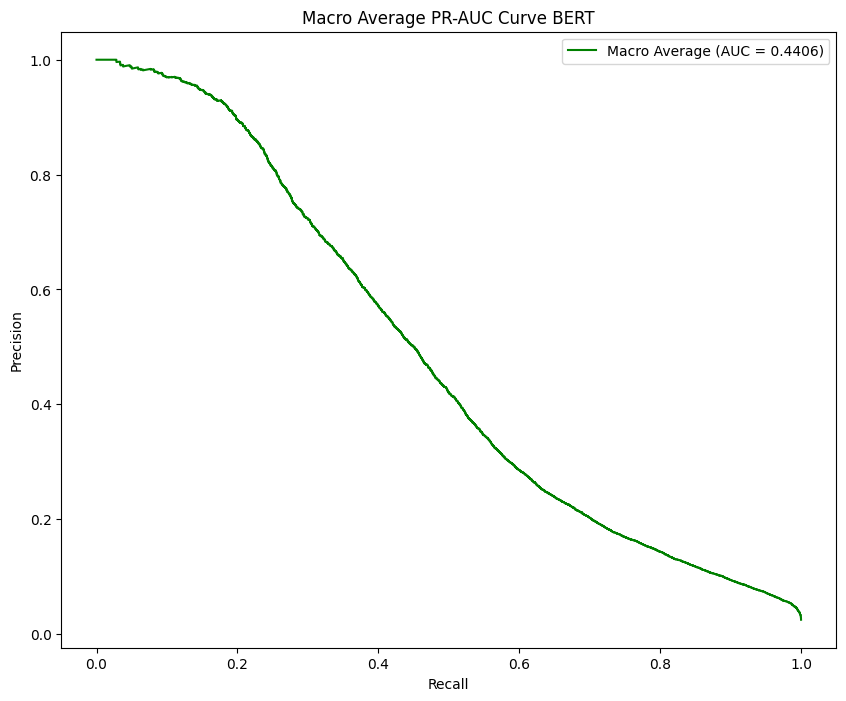

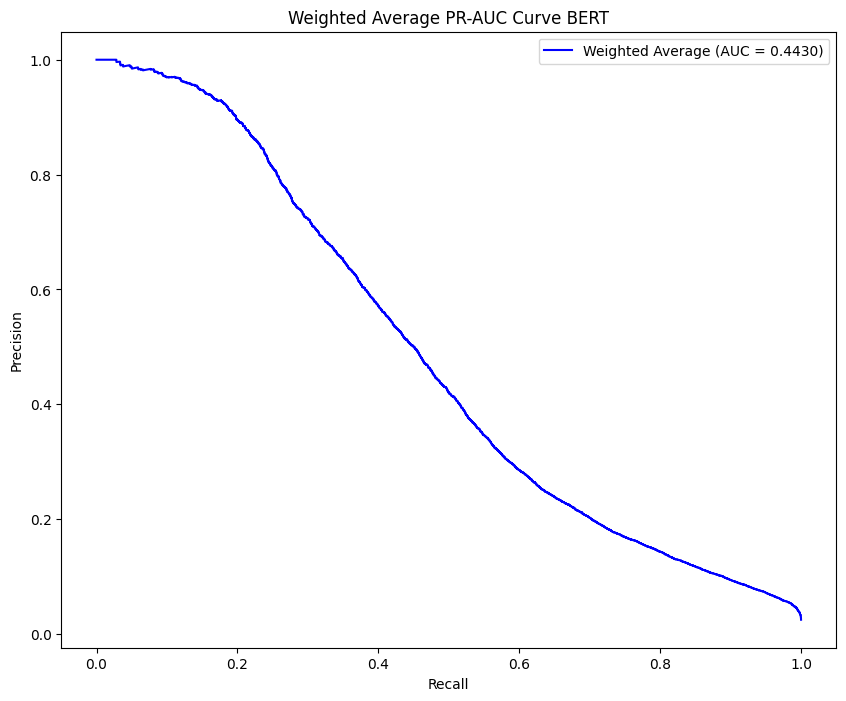

Epoch 3, Loss: 1.63
Validation Loss: 1.65
Validation loss improved. Saving model...
Validation Accuracy: 52.88%
                                precision    recall  f1-score   support

          Allergy / Immunology     0.9094    0.9914    0.9487       233
                       Autopsy     0.9486    0.9062    0.9269       224
                    Bariatrics     0.7970    0.6738    0.7302       233
    Cardiovascular / Pulmonary     0.2095    0.1078    0.1424       204
                  Chiropractic     0.5783    0.8538    0.6895       212
    Consult - History and Phy.     0.3161    0.2426    0.2745       202
    Cosmetic / Plastic Surgery     0.3038    0.6493    0.4139       211
                     Dentistry     0.4355    0.7617    0.5542       235
                   Dermatology     0.4975    0.4739    0.4854       211
          Diets and Nutritions     0.8821    0.9819    0.9293       221
             Discharge Summary     0.6818    0.4478    0.5405       201
          ENT - Otolary

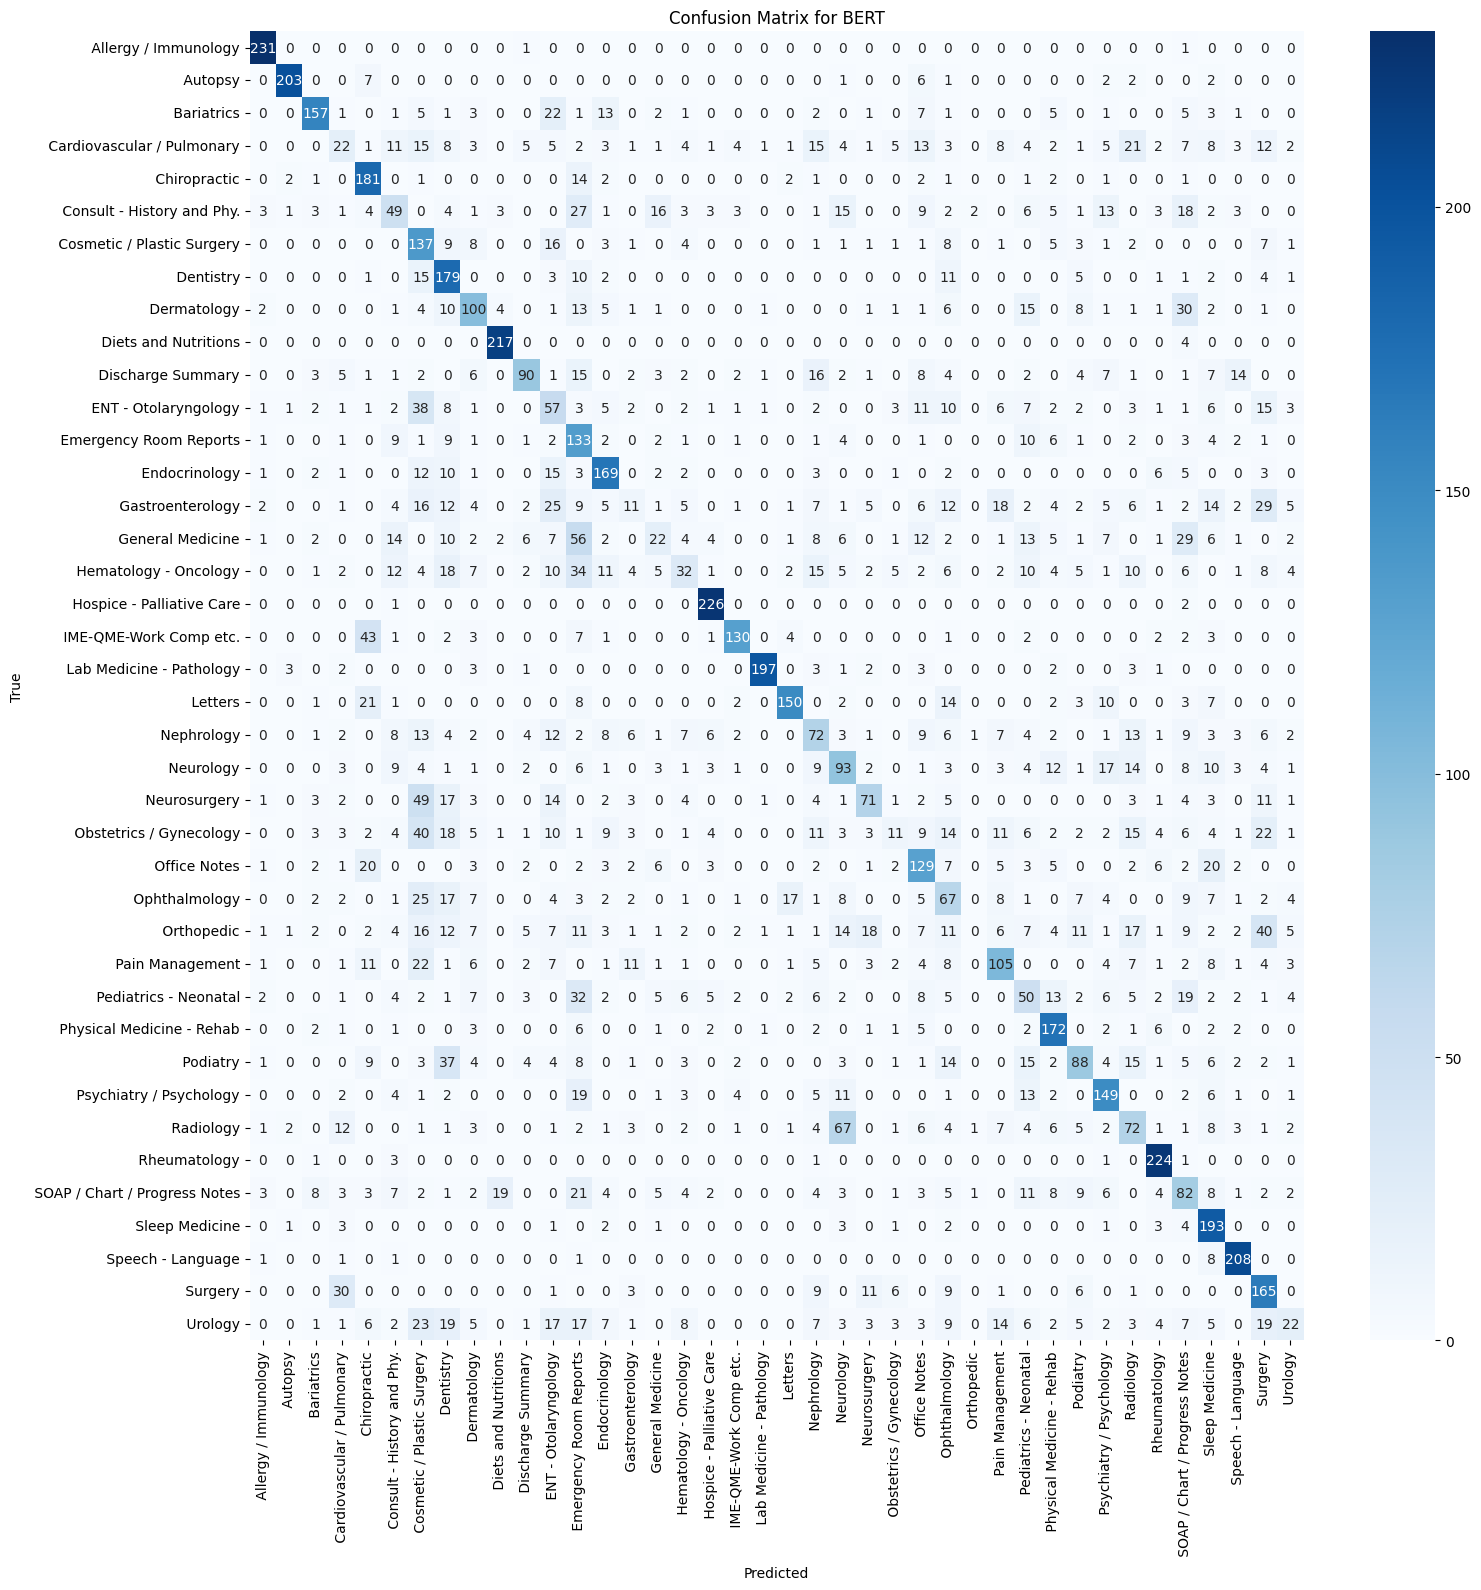

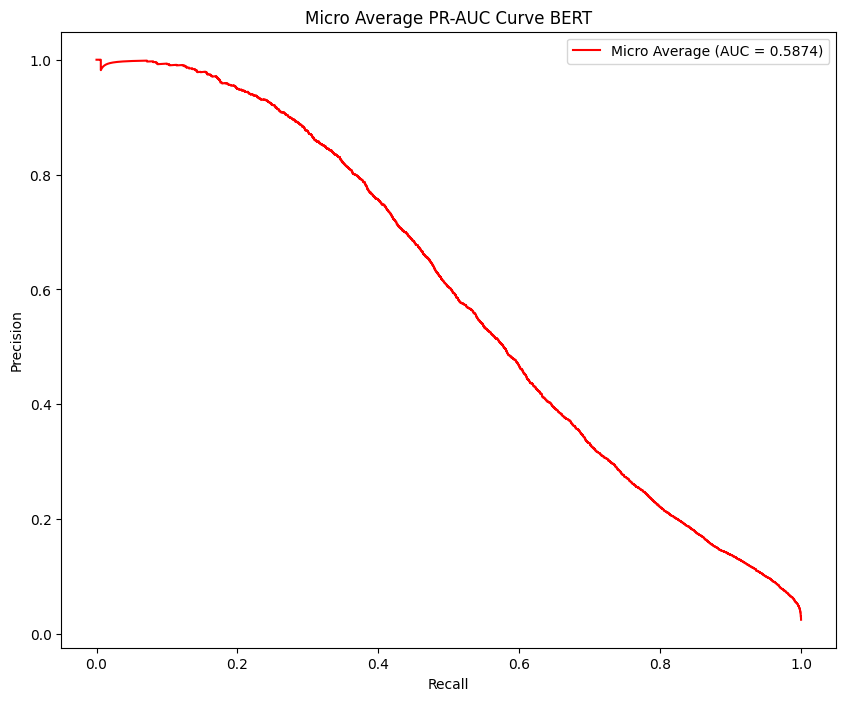

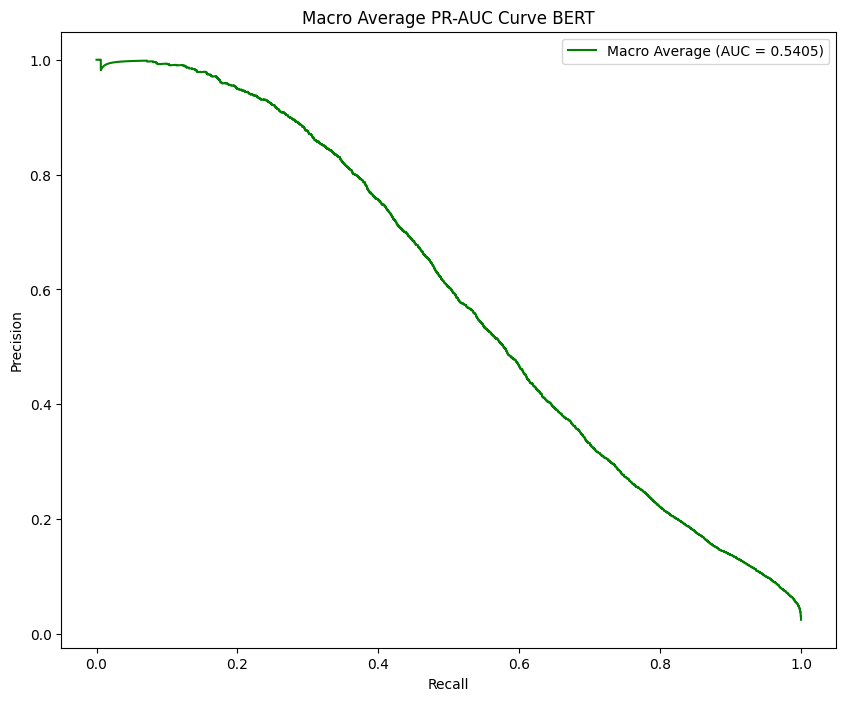

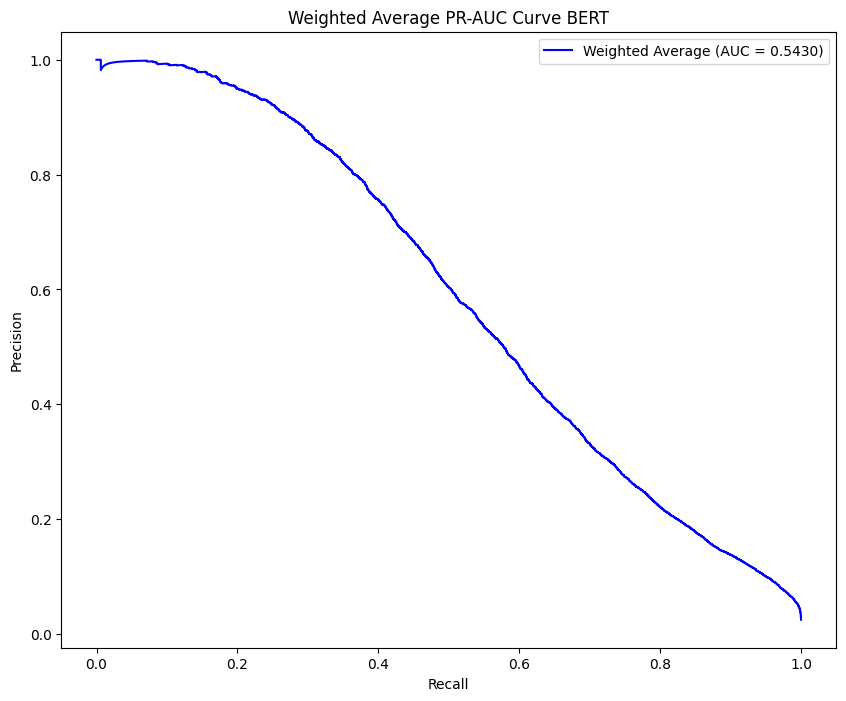

Epoch 4, Loss: 1.20
Validation Loss: 1.57
Validation loss improved. Saving model...
Validation Accuracy: 55.44%
                                precision    recall  f1-score   support

          Allergy / Immunology     0.9532    0.9614    0.9573       233
                       Autopsy     0.9565    0.8839    0.9188       224
                    Bariatrics     0.6332    0.7854    0.7011       233
    Cardiovascular / Pulmonary     0.1712    0.2157    0.1909       204
                  Chiropractic     0.6525    0.7972    0.7176       212
    Consult - History and Phy.     0.2290    0.3515    0.2773       202
    Cosmetic / Plastic Surgery     0.4005    0.7536    0.5230       211
                     Dentistry     0.8794    0.5277    0.6596       235
                   Dermatology     0.6215    0.7393    0.6753       211
          Diets and Nutritions     0.9372    0.8778    0.9065       221
             Discharge Summary     0.6022    0.5423    0.5707       201
          ENT - Otolary

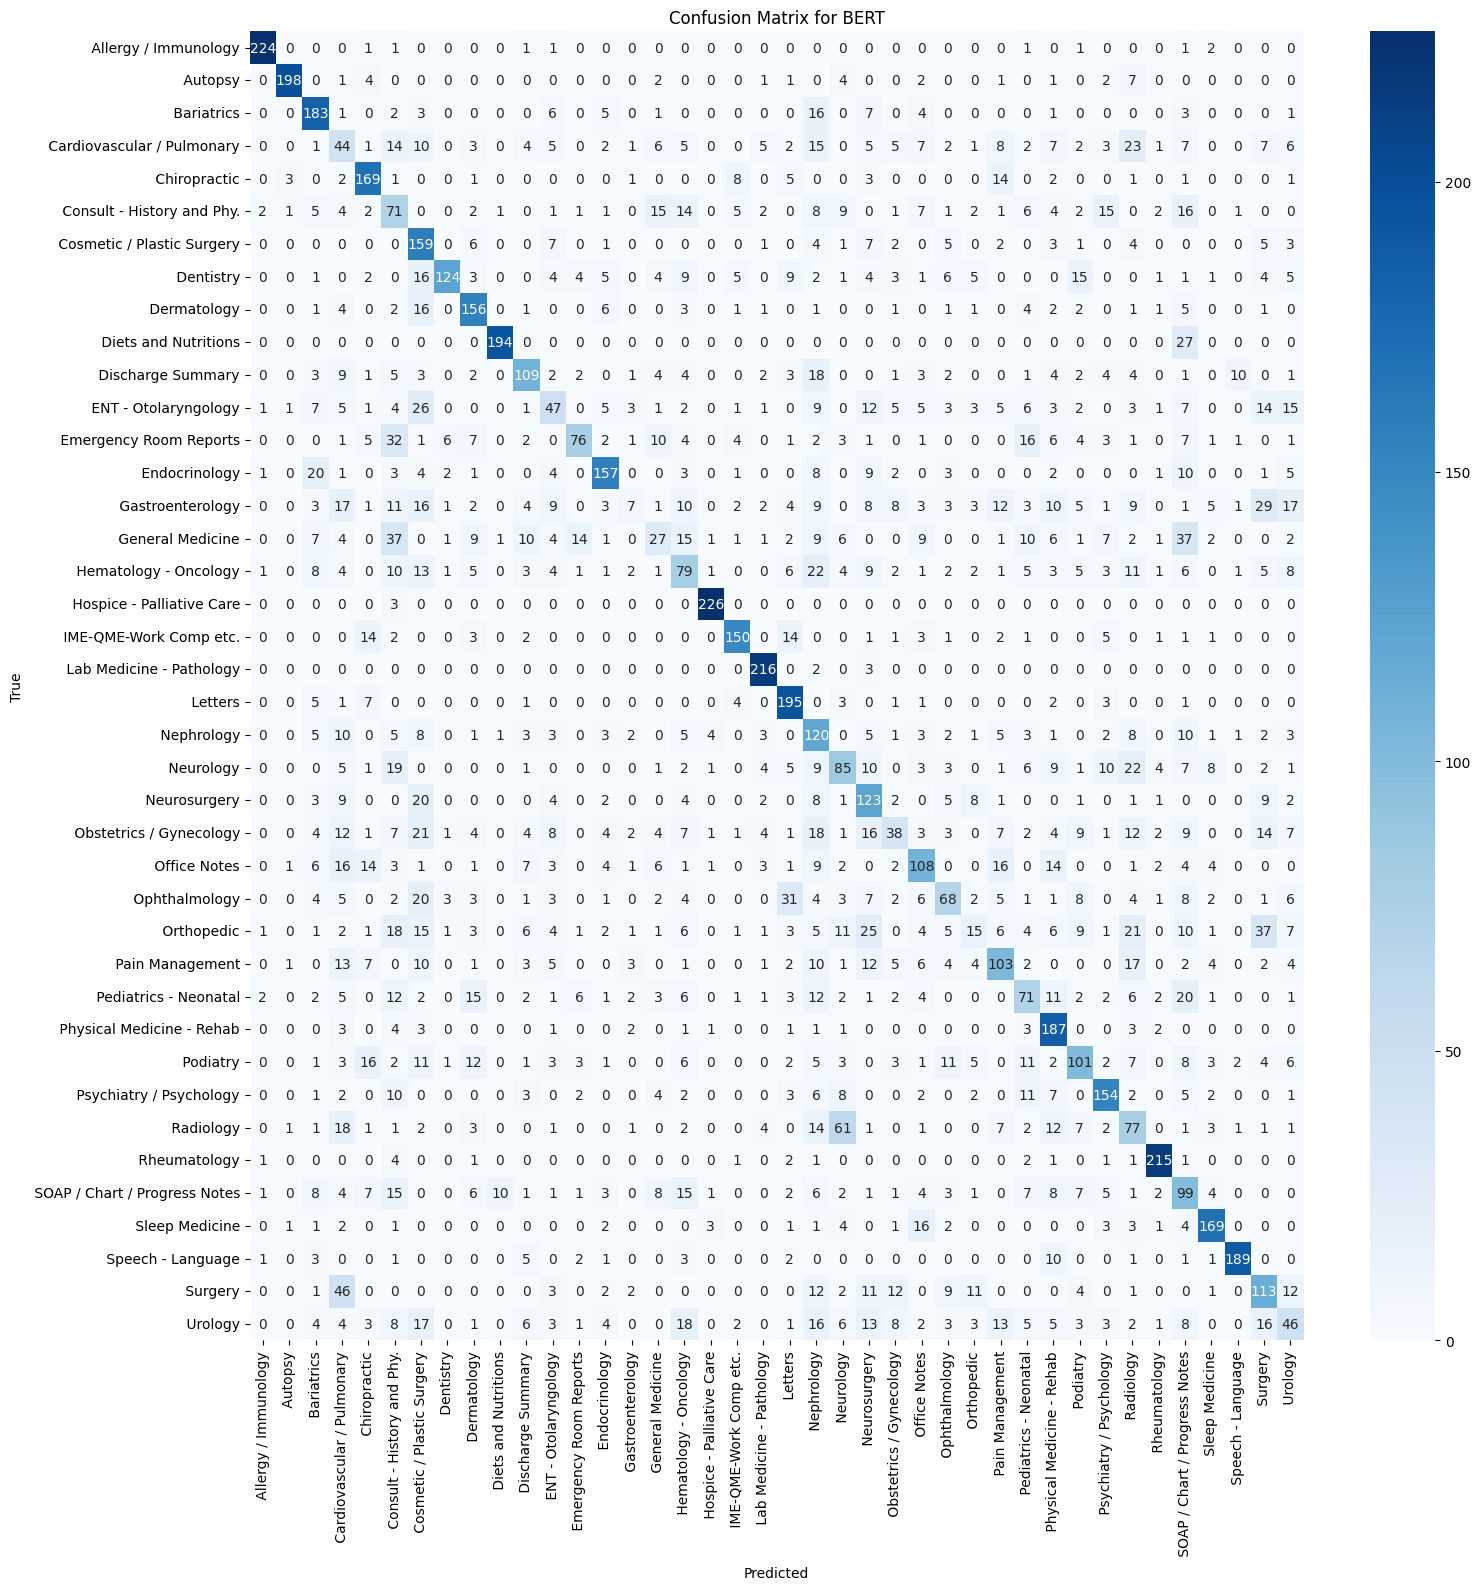

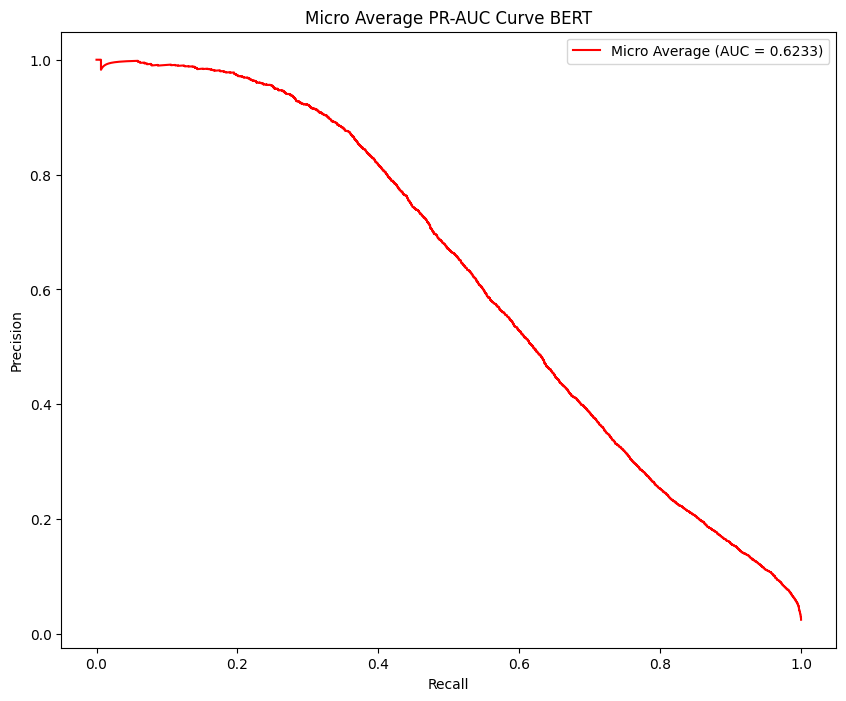

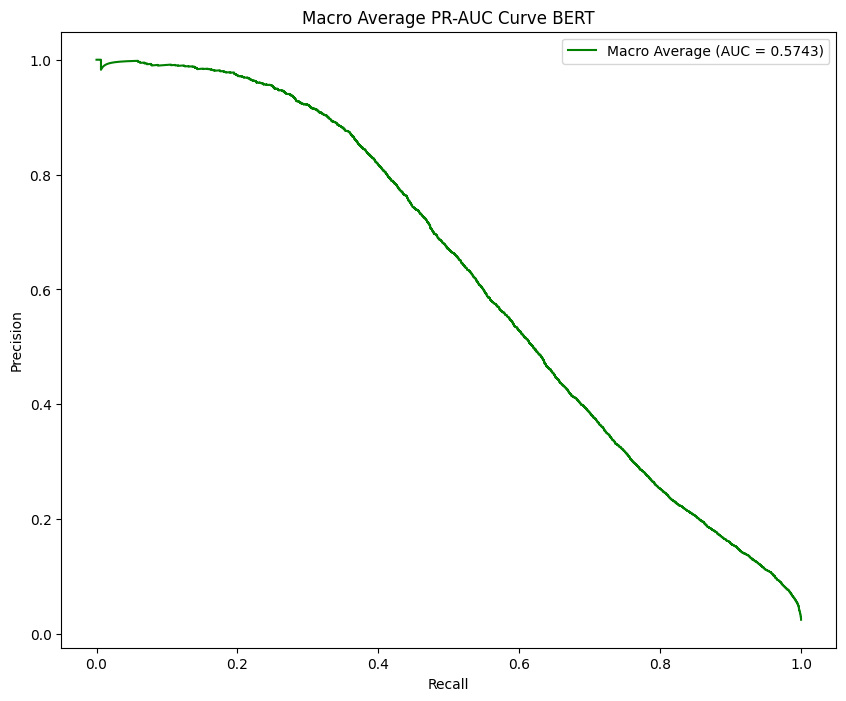

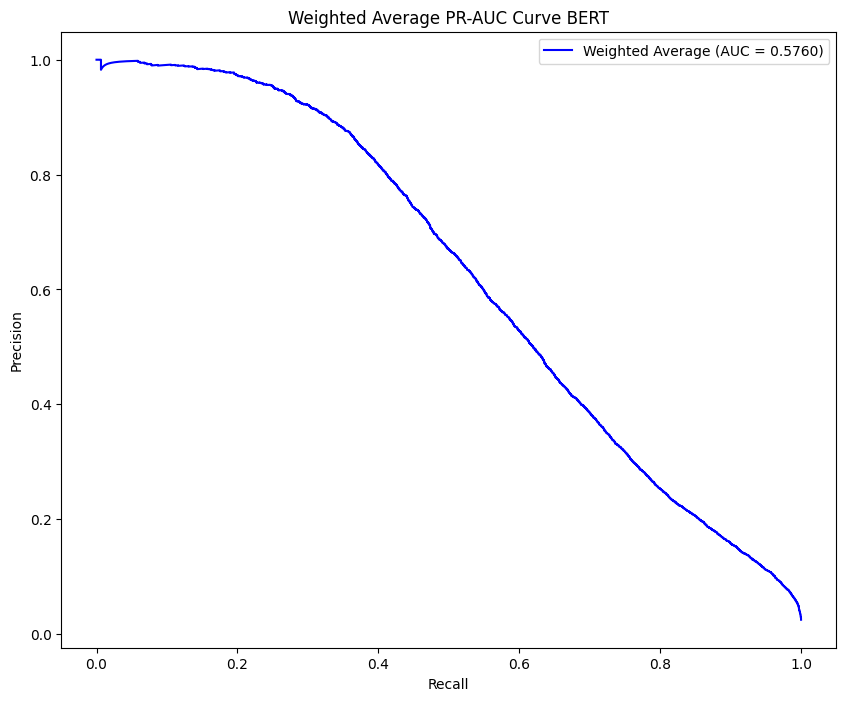

Epoch 5, Loss: 0.89
Validation Loss: 1.58
Validation loss did not improve for 1 epoch(s).
Validation Accuracy: 56.90%
                                precision    recall  f1-score   support

          Allergy / Immunology     0.8885    0.9914    0.9371       233
                       Autopsy     0.9286    0.9286    0.9286       224
                    Bariatrics     0.6446    0.7940    0.7115       233
    Cardiovascular / Pulmonary     0.2235    0.1863    0.2032       204
                  Chiropractic     0.7544    0.8113    0.7818       212
    Consult - History and Phy.     0.1503    0.2574    0.1898       202
    Cosmetic / Plastic Surgery     0.4939    0.7630    0.5996       211
                     Dentistry     0.8742    0.5915    0.7056       235
                   Dermatology     0.6278    0.7915    0.7002       211
          Diets and Nutritions     0.9224    0.9683    0.9448       221
             Discharge Summary     0.4346    0.5622    0.4902       201
          ENT - O

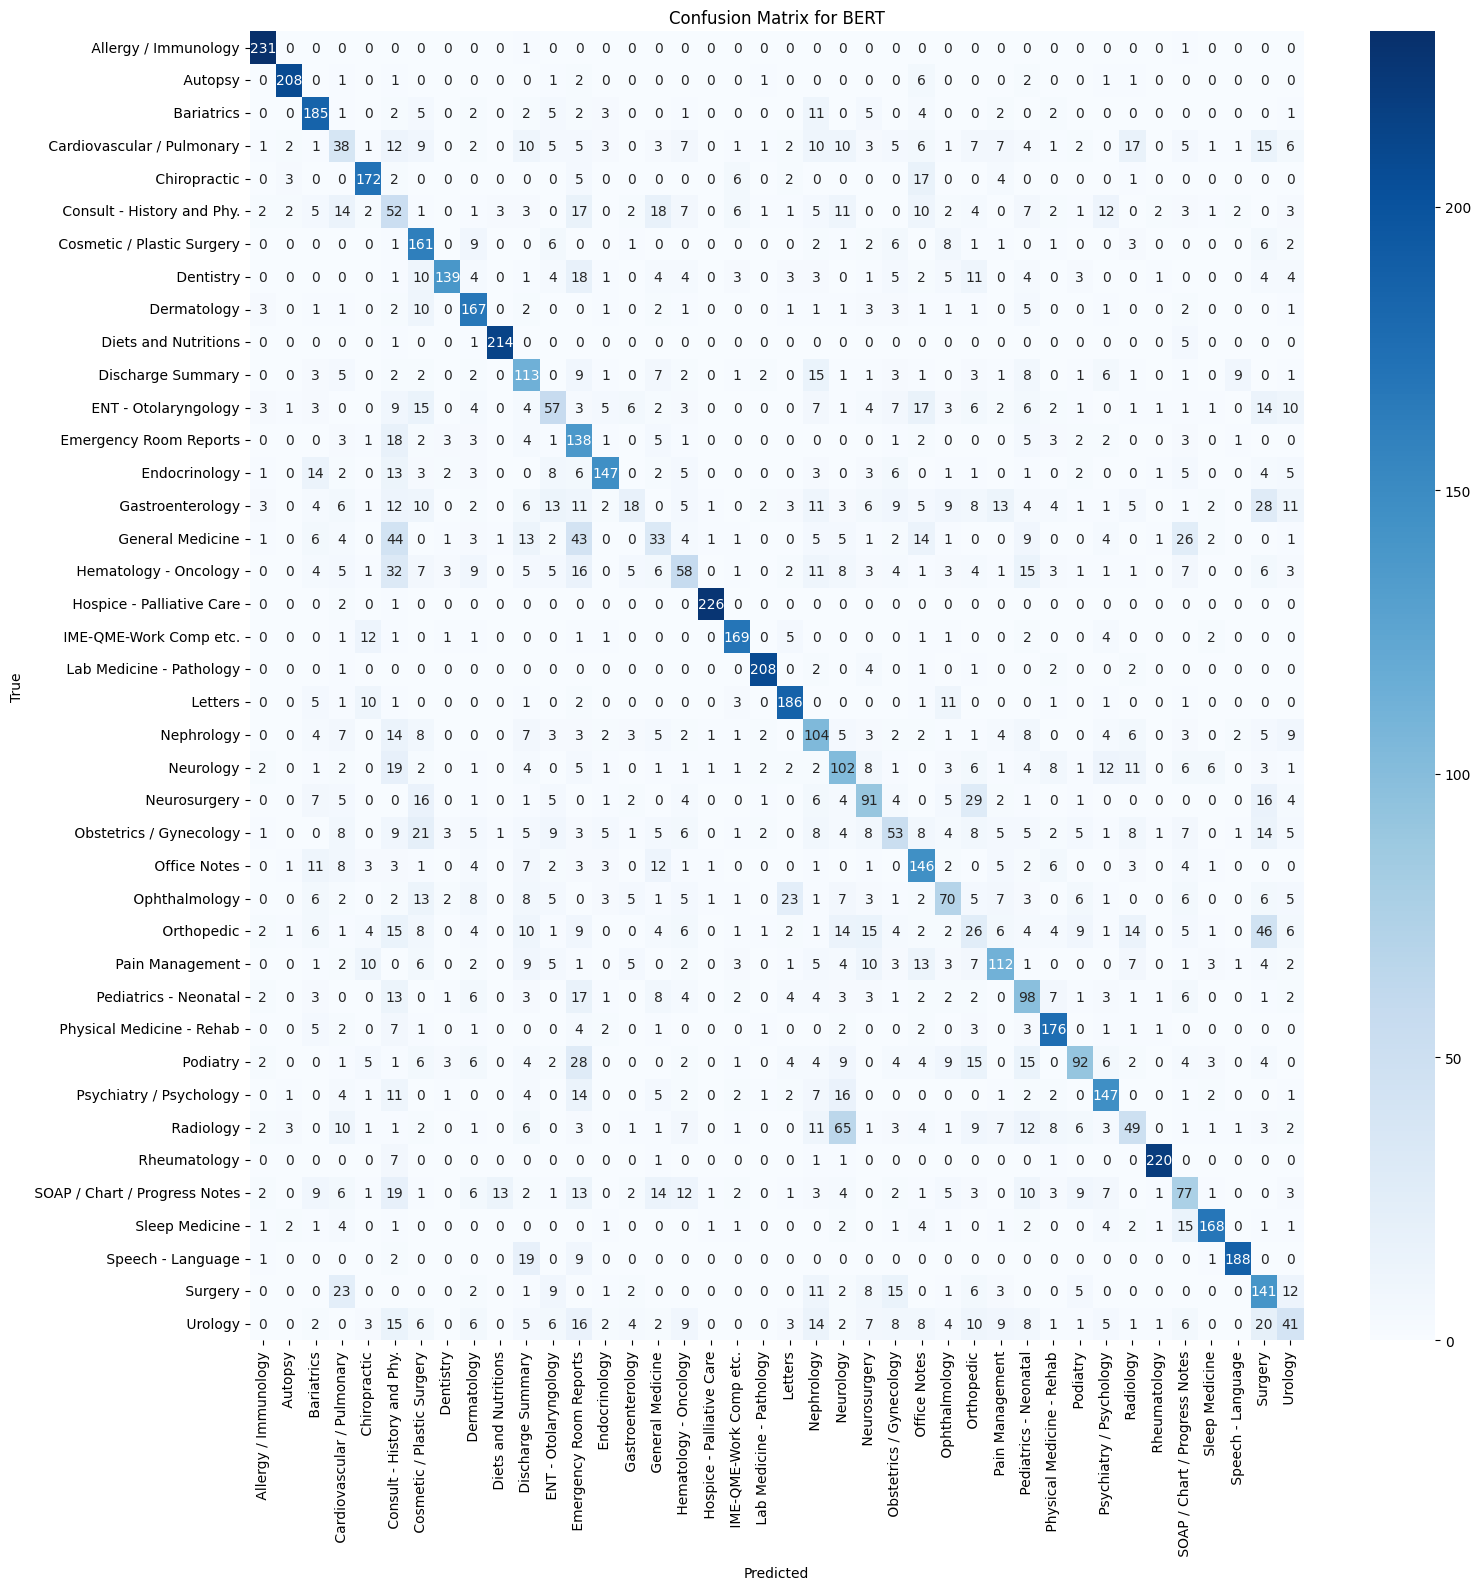

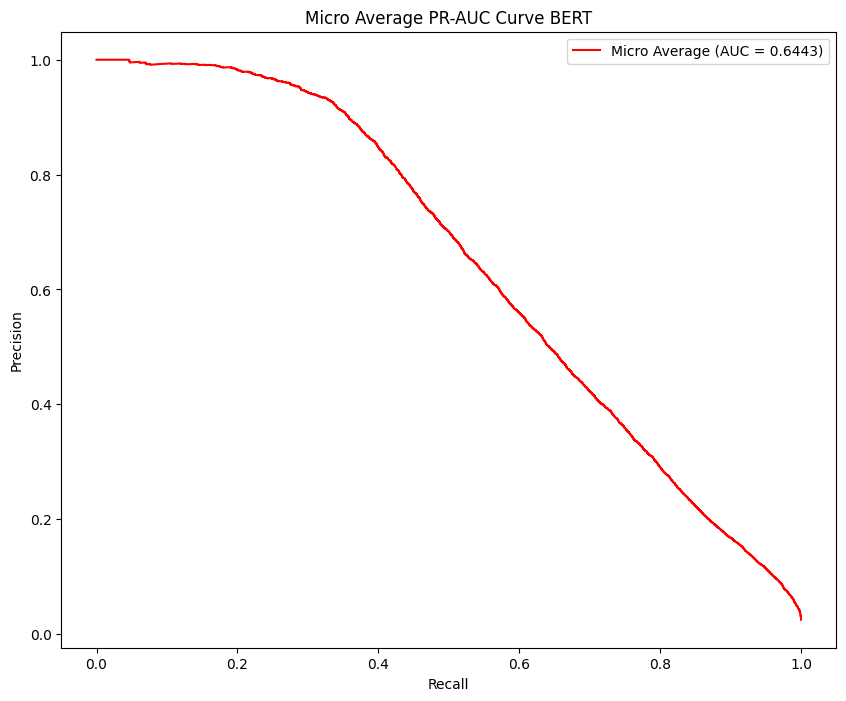

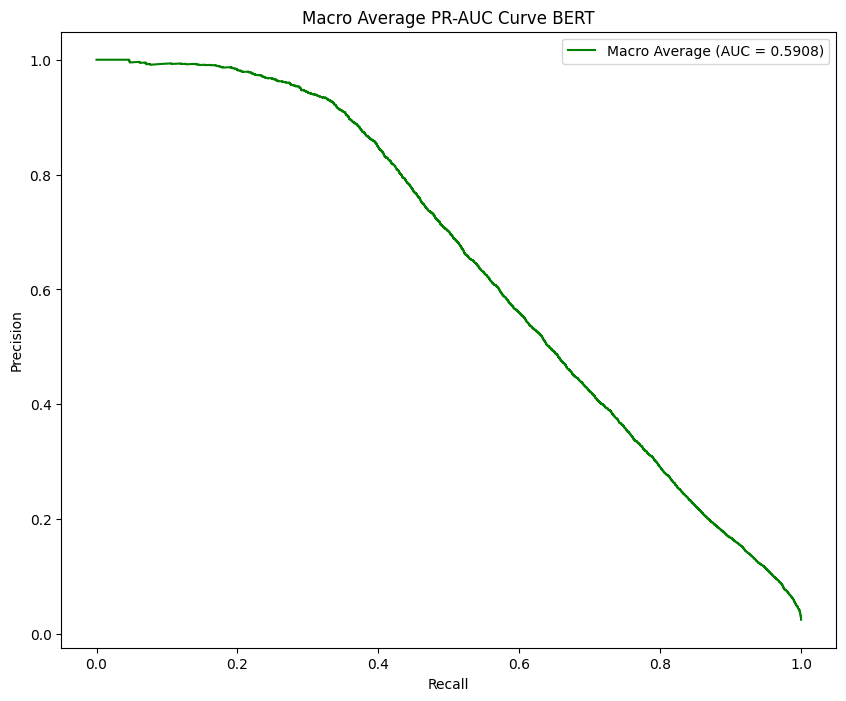

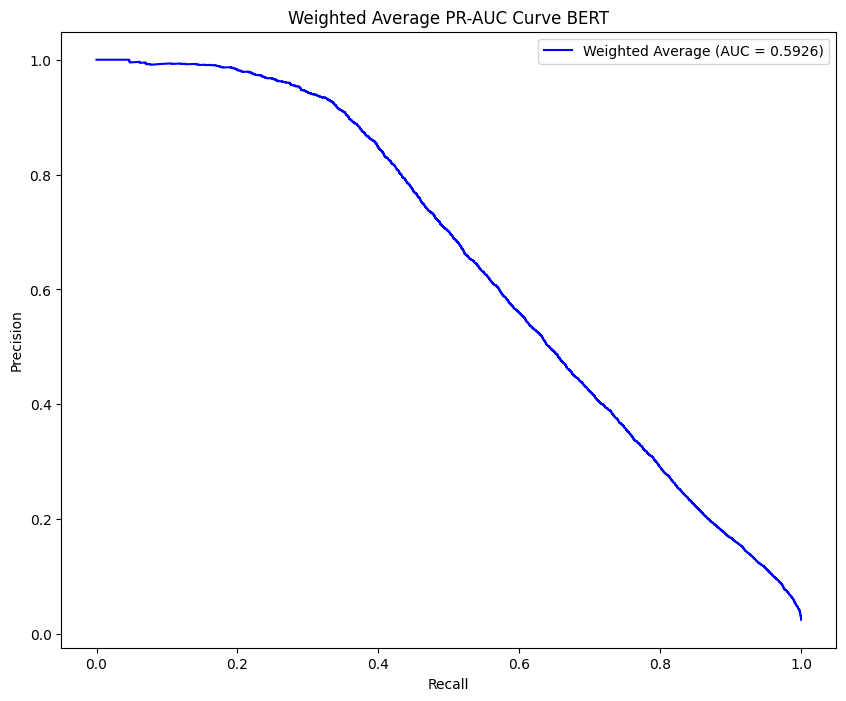

Epoch 6, Loss: 0.65
Validation Loss: 1.71
Validation loss did not improve for 2 epoch(s).
Early stopping triggered.
Validation Accuracy: 56.94%
                                precision    recall  f1-score   support

          Allergy / Immunology     0.9265    0.9742    0.9498       233
                       Autopsy     0.8520    0.9509    0.8987       224
                    Bariatrics     0.6311    0.8369    0.7196       233
    Cardiovascular / Pulmonary     0.1695    0.0980    0.1242       204
                  Chiropractic     0.6965    0.8443    0.7633       212
    Consult - History and Phy.     0.1711    0.2228    0.1935       202
    Cosmetic / Plastic Surgery     0.6348    0.5355    0.5810       211
                     Dentistry     0.6424    0.7872    0.7075       235
                   Dermatology     0.7175    0.7583    0.7373       211
          Diets and Nutritions     0.9118    0.9819    0.9455       221
             Discharge Summary     0.6894    0.4527    0.5465  

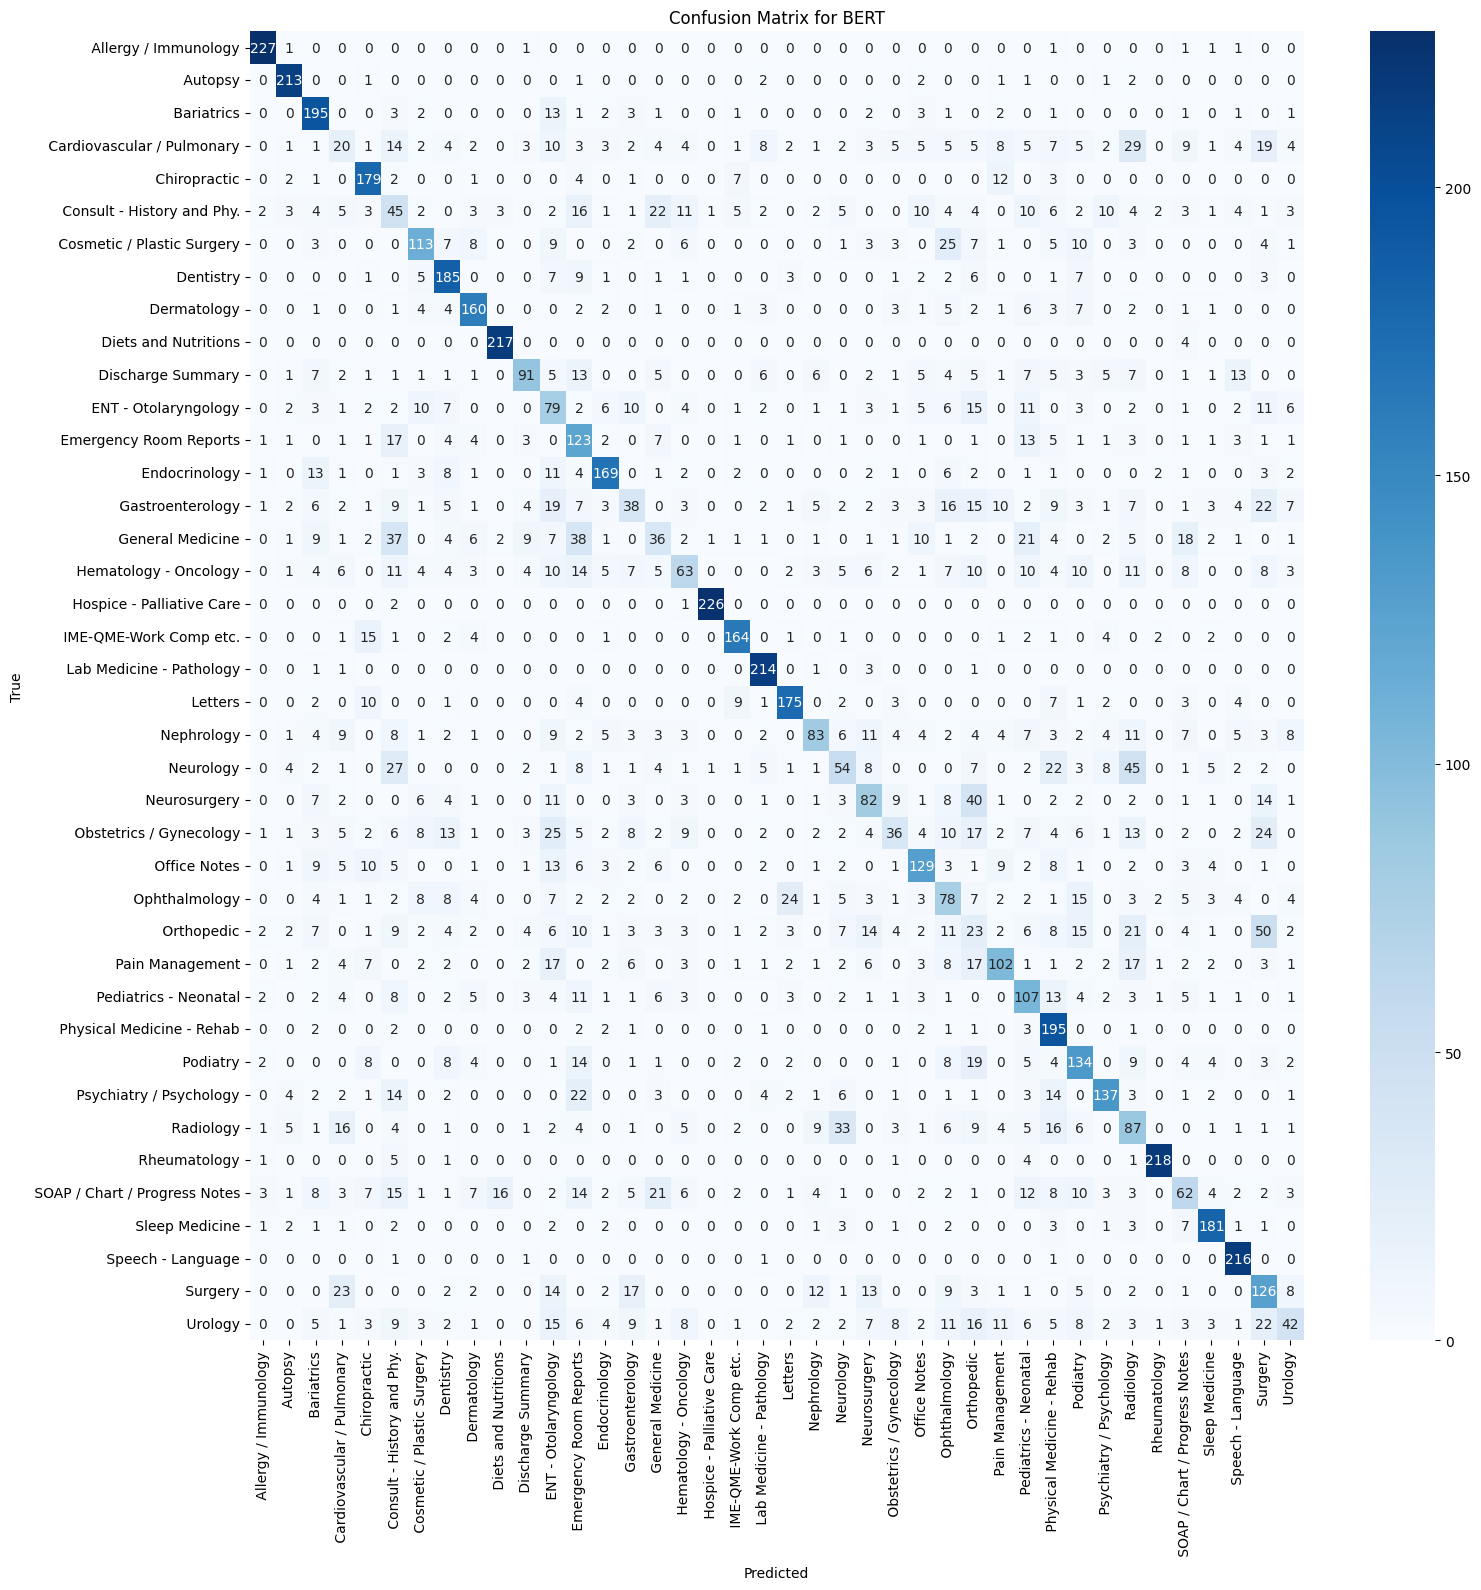

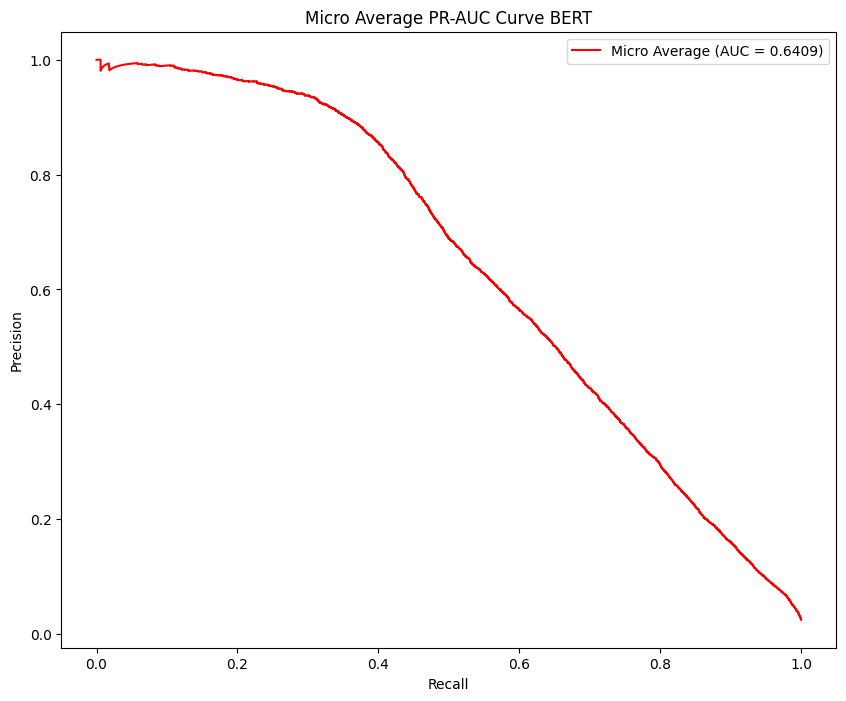

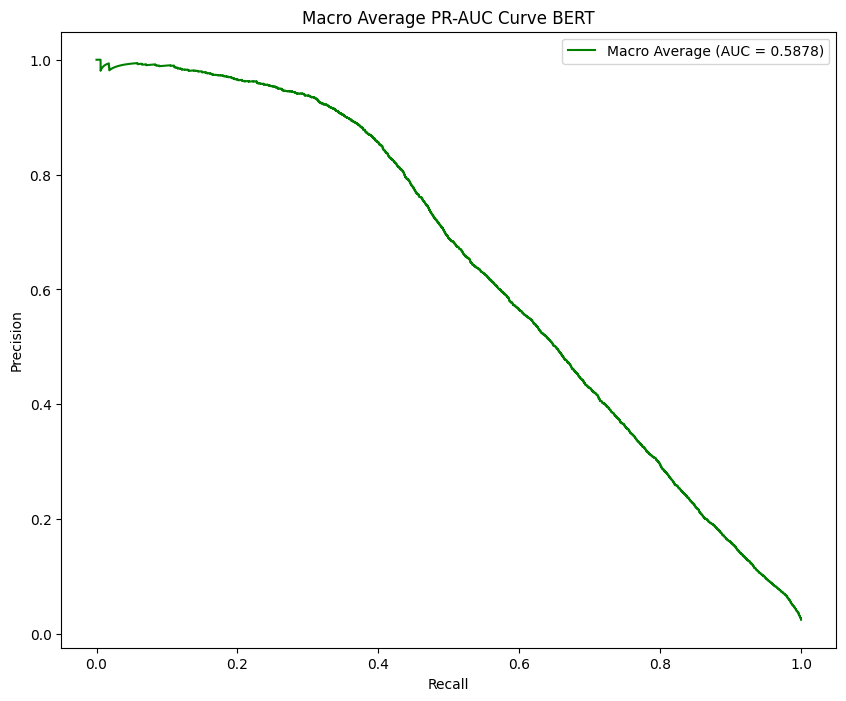

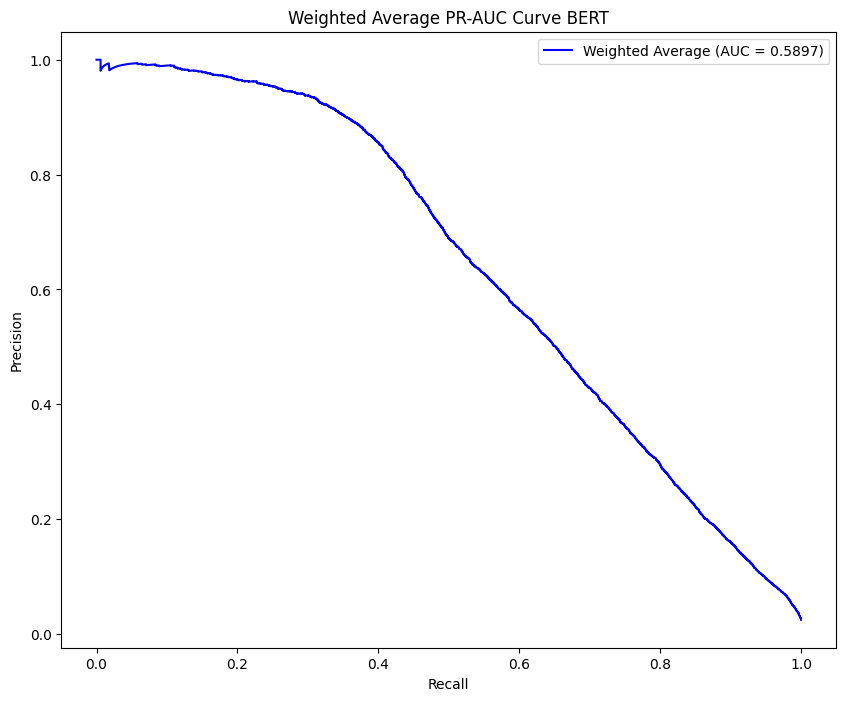

Early stopping triggered.
Training complete


In [9]:
import pandas as pd
import re
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertForSequenceClassification
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Load BERT model and tokenizer for classification
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=40)

# Function to preprocess text
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'\([^)]*\)', '', text)
    text = re.sub('"', '', text)
    text = re.sub(r"'s\b", "", text)
    text = re.sub("[^a-zA-Z]", " ", text)
    return text.strip()

# Load data
data = pd.read_csv('/kaggle/input/medicaltranscriptions/mtsamples.csv')
data.drop('Unnamed: 0', axis=1, inplace=True)

# Clean transcription
data['cleaned_transcription'] = data['transcription'].apply(preprocess_text)

# Tokenize and encode the texts
def encode_texts(texts):
    inputs = tokenizer(texts.tolist(), return_tensors='pt', padding=True, truncation=True, max_length=64)
    return inputs['input_ids'], inputs['attention_mask']

# Create embeddings for transcripts
input_ids, attention_masks = encode_texts(data.cleaned_transcription)

# Label encode our categorical target variable
le = LabelEncoder()
Y = le.fit_transform(data.medical_specialty.values)

# Applying SMOTE to balance classes
sm = SMOTE()
X_res, Y_res = sm.fit_resample(input_ids.numpy(), Y)
#attention_masks_res, _ = sm.fit_resample(attention_masks.numpy(), Y)

# Splitting data into train:test
X_train, X_val, Y_train, Y_val = train_test_split(X_res, Y_res, test_size=0.2, random_state=42)

print('\nTraining features shape: ', X_train.shape)
print('Validation features shape: ', X_val.shape)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.long)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.long)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.long)
#mask_train_tensor = torch.tensor(mask_train, dtype=torch.long)
#mask_val_tensor = torch.tensor(mask_val, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, mask_train_tensor, Y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, mask_val_tensor, Y_val_tensor)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Training function with Early Stopping
def train_model_with_early_stopping(model, train_dataloader, val_dataloader, num_epochs=20, accumulation_steps=2, patience=2):
    optimizer = AdamW(model.parameters(), lr=5e-5)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    best_val_loss = float('inf')
    epochs_without_improvement = 0
    early_stop = False

    for epoch in range(num_epochs):
        if early_stop:
            print("Early stopping triggered.")
            break

        model.train()
        total_loss = 0

        # Training loop
        for batch in train_dataloader:
            optimizer.zero_grad()
            inputs, masks, labels = batch
            inputs = inputs.to(device)
            masks = masks.to(device)
            labels = labels.to(device)
            outputs = model(input_ids=inputs, attention_mask=masks, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

        avg_loss = total_loss / len(train_dataloader)
        print(f"Epoch {epoch + 1}, Loss: {avg_loss:.2f}")

        # Validation
        model.eval()
        val_loss = 0.0
        val_preds, val_labels, val_probs = [], [], []
        with torch.no_grad():
            for batch in val_dataloader:
                inputs, masks, labels = batch
                inputs = inputs.to(device)
                masks = masks.to(device)
                labels = labels.to(device)
                outputs = model(input_ids=inputs, attention_mask=masks, labels=labels)
                val_loss += outputs.loss.item()
                logits = outputs.logits
                probs = torch.softmax(logits, dim=1)

                val_preds.append(logits.argmax(dim=1).cpu().numpy())
                val_labels.append(labels.cpu().numpy())
                val_probs.append(probs.cpu().numpy())

        avg_val_loss = val_loss / len(val_dataloader)
        print(f"Validation Loss: {avg_val_loss:.2f}")

        # Check for improvement in validation loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
            print("Validation loss improved. Saving model...")
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_without_improvement += 1
            print(f"Validation loss did not improve for {epochs_without_improvement} epoch(s).")

        # Early stopping condition
        if epochs_without_improvement >= patience:
            early_stop = True
            print("Early stopping triggered.")

        # Evaluation metrics after each epoch
        val_preds = np.concatenate(val_preds)
        val_labels = np.concatenate(val_labels)
        val_probs = np.concatenate(val_probs)

        accuracy = accuracy_score(val_labels, val_preds)
        print(f"Validation Accuracy: {accuracy * 100:.2f}%")
        print(classification_report(val_labels, val_preds, target_names=le.classes_, digits=4, zero_division=0))

        # Confusion Matrix
        conf_matrix = confusion_matrix(val_labels, val_preds)
        plt.figure(figsize=(17, 17))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
        plt.title('Confusion Matrix for BERT')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.savefig('confusion_matrix.png')
        plt.show()

        # Compute Model-Level Precision-Recall Curves (Micro, Macro, Weighted)
        from sklearn.preprocessing import label_binarize

        # Binarize the labels for one-vs-rest computation
        val_labels_bin = label_binarize(val_labels, classes=np.arange(len(le.classes_)))

        # Micro-average PR-AUC
        precision_micro, recall_micro, _ = precision_recall_curve(val_labels_bin.ravel(), val_probs.ravel())
        pr_auc_micro = average_precision_score(val_labels_bin, val_probs, average='micro')

        # Macro-average PR-AUC (model-level, no per-class curves)
        pr_auc_macro = average_precision_score(val_labels_bin, val_probs, average='macro')

        # Weighted-average PR-AUC
        pr_auc_weighted = average_precision_score(val_labels_bin, val_probs, average='weighted')

        # Plotting the PR-AUC curves
        # Micro Average PR-AUC Plot
        plt.figure(figsize=(10, 8))
        plt.plot(recall_micro, precision_micro, label=f'Micro Average (AUC = {pr_auc_micro:.4f})', color='red')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Micro Average PR-AUC Curve BERT')
        plt.legend()
        plt.savefig('micro_pr_auc.png')
        plt.show()

        # Macro Average PR-AUC Plot (using micro curve as proxy, showing model-level AP)
        plt.figure(figsize=(10, 8))
        plt.plot(recall_micro, precision_micro, label=f'Macro Average (AUC = {pr_auc_macro:.4f})', color='green')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Macro Average PR-AUC Curve BERT')
        plt.legend()
        plt.savefig('macro_pr_auc.png')
        plt.show()

        # Weighted Average PR-AUC Plot
        plt.figure(figsize=(10, 8))
        plt.plot(recall_micro, precision_micro, label=f'Weighted Average (AUC = {pr_auc_weighted:.4f})', color='blue')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Weighted Average PR-AUC Curve BERT')
        plt.legend()
        plt.savefig('weighted_pr_auc.png')
        plt.show()

    print("Training complete")

# Train the model with early stopping
train_model_with_early_stopping(model, train_dataloader, val_dataloader, num_epochs=25, patience=2)